# 4 — Valutazione quantitativa

100 MRI sintetiche (modello finale: **curriculum a due fasi** + **autoguidance** w=2.0, checkpoint epoch 800) confrontate con le reali, su **test set** (102 hold-out) e **intero dataset** (1007):

- **FID 2.5D** (XY/YZ/ZX + media): realismo distribuzionale. Piu' basso = meglio.
- **MMD**: distanza distribuzionale complementare. Piu' basso = meglio.
- **MS-SSIM** intra-set: diversita' (mode collapse). *Interpretabile solo a campioni allineati.*
- **QC geometrico** (`check_degenerate_samples.py`): frazione di campioni fuori posizione. Cattura l'artefatto che FID e MS-SSIM non vedono.

In [1]:
import os, sys, json, glob
ROOT=os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

def show_ortho(vol, title=None, ax_row=None, cmap="gray"):
    """Mostra le 3 viste ortogonali (centrali) di un volume 3D."""
    if hasattr(vol, "numpy"):
        vol=vol.numpy()
    vol=np.asarray(vol).squeeze()
    x, y, z=[s // 2 for s in vol.shape]
    views=[(np.rot90(vol[x, :, :]), "Sagittale"),
             (np.rot90(vol[:, y, :]), "Coronale"),
             (np.rot90(vol[:, :, z]), "Assiale")]
    axes=ax_row if ax_row is not None else plt.subplots(1, 3, figsize=(12, 4))[1]
    for a, (img, name) in zip(axes, views):
        a.imshow(img, cmap=cmap); a.set_title(name); a.axis("off")
    if title and ax_row is None:
        plt.suptitle(title); plt.tight_layout()
    return axes


## Tabella riassuntiva delle metriche

In [2]:
with open("outputs/metrics/eval_test_v5.json") as f: ev_test=json.load(f)
with open("outputs/metrics/eval_all_v5.json") as f: ev_all=json.load(f)

rows = [
    ("FID XY",        "fid_xy"),
    ("FID YZ",        "fid_yz"),
    ("FID ZX",        "fid_zx"),
    ("FID medio",     "fid_avg"),
    ("MMD",           "mmd"),
    ("MS-SSIM sint",  "msssim_synth"),
    ("MS-SSIM reali", "msssim_real"),
]
h_metric, h_test, h_all="Metrica", "test (102)", "all (1007)"
print(f"{h_metric:<15}{h_test:>14}{h_all:>14}")
print("-"*43)
for name, key in rows:
    print(f"{name:<15}{ev_test[key]:>14.4f}{ev_all[key]:>14.4f}")

Metrica            test (102)    all (1007)
-------------------------------------------
FID XY                25.5043       24.8522
FID YZ                27.2600       26.6470
FID ZX                20.1658       20.0763
FID medio             24.3100       23.8585
MMD                    0.0089        0.0089
MS-SSIM sint           0.9486        0.9486
MS-SSIM reali          0.9357        0.9355


## Selezione dei checkpoint: curva FID-vs-epoca

Selezione grezza (senza autoguidance) su tutti i checkpoint periodici dell'LDM.

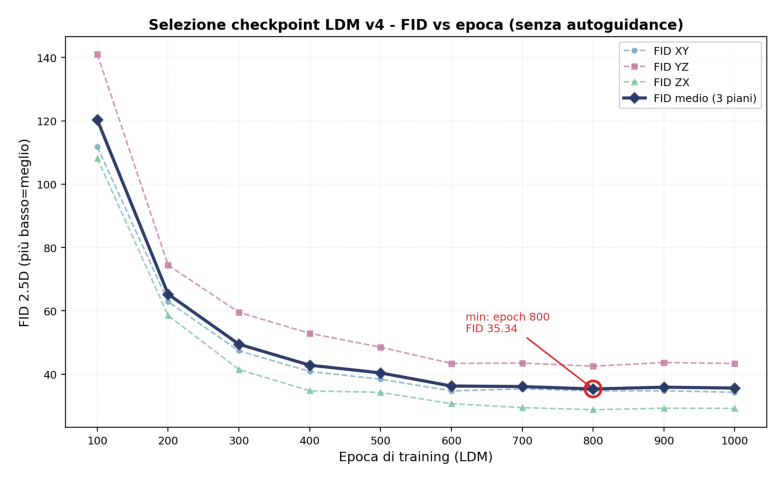

In [3]:
fig_path="outputs/metrics/fid_vs_epoch_v5.png"
if os.path.exists(fig_path):
    fig, ax=plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(fig_path)); ax.axis("off"); plt.show()
else:
    from src.evaluation.plot_fid_curve import plot_fid_curve
    plot_fid_curve("outputs/checkpoint_selection_v5/fid_by_checkpoint_v5.json",
                   save_path=fig_path)
    plt.show()

## Effetto dell'autoguidance sui checkpoint migliori

Raffinamento dei top-3 della curva precedente, rivalutati **con** autoguidance.

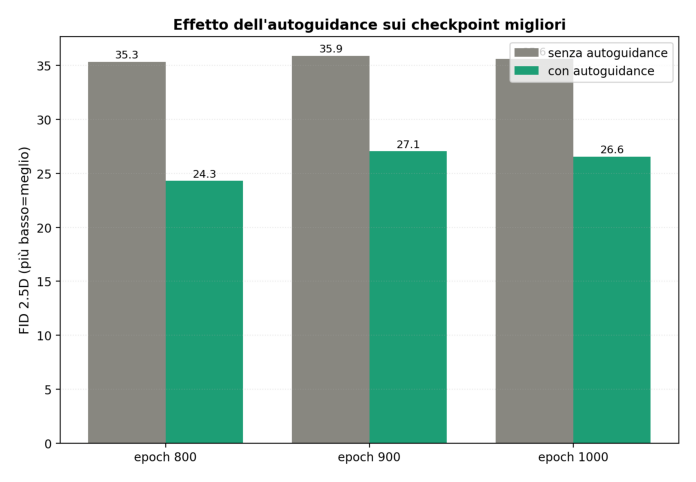

In [4]:
fig_path="outputs/metrics/fid_autoguidance_top_v5.png"
if os.path.exists(fig_path):
    fig, ax=plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(fig_path)); ax.axis("off"); plt.show()
else:
    print(f"{fig_path} non trovato (eseguire checkpoint_selection.py con --refine_top)")

## Lettura dei risultati

**Realismo.** FID medio **24.31** su test (102) e **23.86** su all (1007): stima stabile al variare del riferimento. Rispetto al baseline (FID ~39) il miglioramento e' del **~38%**.

**Il curriculum risolve il trade-off della v4.** Confronto fra le tre configurazioni del campionamento dei timestep (tutte con autoguidance w=2.0):

| config | FID test | MMD | MS-SSIM sint | traslazioni |
|---|---|---|---|---|
| logit-normal statico | 21.8 | 0.019 | 0.895 | ~20% |
| uniform statico | 27.2 | 0.0089 | 0.947 | 0% |
| **curriculum (finale)** | **24.3** | **0.0089** | **0.949** | **0%** |

Il logit-normal statico dava il FID piu' basso ma ~20% di campioni **traslati** (struttura globale appresa male, per il sotto-campionamento dei timestep ad alto rumore); l'uniform statico azzerava le traslazioni al costo di ~5 punti di FID. Il **curriculum** (fase 1 uniform -> fase 2 logit-normal) recupera meta' del vantaggio di nitidezza del logit-normal (FID 24.3) **senza alcun costo geometrico** (0% traslati, verificato con e senza guida), pareggiando l'uniform su MMD e MS-SSIM.

**Concordanza fra metriche.** MMD **0.0089** su entrambi i riferimenti, coerente col FID.

**Diversita'.** MS-SSIM sintetiche **0.9486** vs reali **0.9356**: lievemente piu' simili tra loro dei reali ma **nessun mode collapse**. Interpretabile perche' i campioni sono allineati (a differenza del logit-normal statico, dove 0.895 era depresso *artificialmente* dalle traslazioni).

**Uniformita' fra piani.** FID XY/YZ/ZX = 25.50/27.26/20.17 (test): il divario sagittale-assiale e' il piu' contenuto fra tutte le configurazioni.

**Artefatto di posizionamento (risultato metodologico).** Ne' il **FID** (aggrega slice sull'intero volume: una traslazione lascia il set quasi invariato) ne' la **MS-SSIM** rilevano lo spostamento globale: e' stato individuato per **ispezione visiva** e quantificato con una metrica geometrica dedicata (centroide/estensione/frazione di tessuto vs distribuzione dei reali). L'esperimento controllato (unica variabile il campionamento dei timestep) ha attribuito l'artefatto al logit-normal statico e mostrato che il curriculum lo elimina.

**Selezione dei checkpoint.** Il raffinamento con autoguidance ha ribaltato la classifica (best senza guida != best con guida), confermando la necessita' del raffinamento dei top-K. Modello finale: checkpoint epoch 800 (bad epoch 200, w=2.0).